#  PCA y Clustering GMM Probabilístico
Reduce la dimensionalidad y agrupa los píxeles válidos en clases composicionales neutras. Evaluamos el número óptimo de clases $K$ mediante BIC.

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from xrf.segmentation.xrf_gmm import Xrf_Gmm_Segmenter
from xrf.spatial.spatial_analyzer import Spatial_Analyzer
from xrf.config import Xrf_Segmentation_Config

In [8]:
# Project directory and data paths
PROJECT_DIR = Path.cwd()

# Find project root directory
while not (PROJECT_DIR / "src").exists():
    PROJECT_DIR = PROJECT_DIR.parent

# Data path
# Load raw data

DATA_DIR = PROJECT_DIR / "data" / "xrf"
RAW_DATA_DIR = DATA_DIR / "raw"
OUTPUT_DATA_DIR = DATA_DIR / "output"
FIGURES_DIR = OUTPUT_DATA_DIR / "figures"
DIAG_DIR = OUTPUT_DATA_DIR / "diagnostics"
PROCESSED_DATA_DIR = OUTPUT_DATA_DIR / "processed"

# CHECK IF FIGURES_DIR EXISTS, IF NOT CREATE IT
if not FIGURES_DIR.exists():
    FIGURES_DIR.mkdir(parents=True, exist_ok=True)

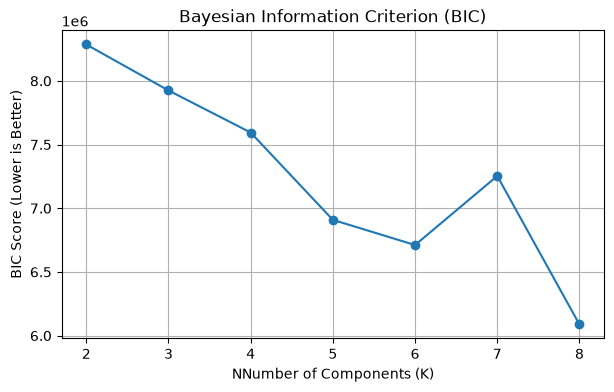

In [9]:
clr_data = np.load(PROCESSED_DATA_DIR / "page_001_clr.npy")
seg_config = Xrf_Segmentation_Config()
k_range = list(range(seg_config.Gmm_Min_K, seg_config.Gmm_Max_K + 1))

# Calcular curvas BIC
bic_scores = Xrf_Gmm_Segmenter.Compute_Bic_Curve(
    clr_data, K_Range=k_range, Variance_Ratio=seg_config.Pca_Variance_Ratio
)

plt.figure(figsize=(7, 4))
plt.plot(list(bic_scores.keys()), list(bic_scores.values()), marker="o")
plt.title("Bayesian Information Criterion (BIC)")
plt.xlabel("NNumber of Components (K)")
plt.ylabel("BIC Score (Lower is Better)")
plt.grid(True)
plt.show()

In [10]:
import json


#Choose the optimal K visually (e.g., K=4)
optimal_k = 8
labels, probabilities, pca_model, gmm_model = Xrf_Gmm_Segmenter.Fit_Predict(
    clr_data,
    Num_Components=optimal_k,
    Variance_Ratio=seg_config.Pca_Variance_Ratio,
    Covariance_Type=seg_config.Covariance_Type,
)

# Guardar los resultados para el cuaderno 04
np.save(PROCESSED_DATA_DIR / "page_001_labels.npy", labels)


# Guardar metadata (optimal_k)
with open(PROCESSED_DATA_DIR / "page_001_meta.json", "w") as f:
    json.dump({"optimal_k": optimal_k}, f)
print("Labels and metadata exported successfully.")

Labels and metadata exported successfully.


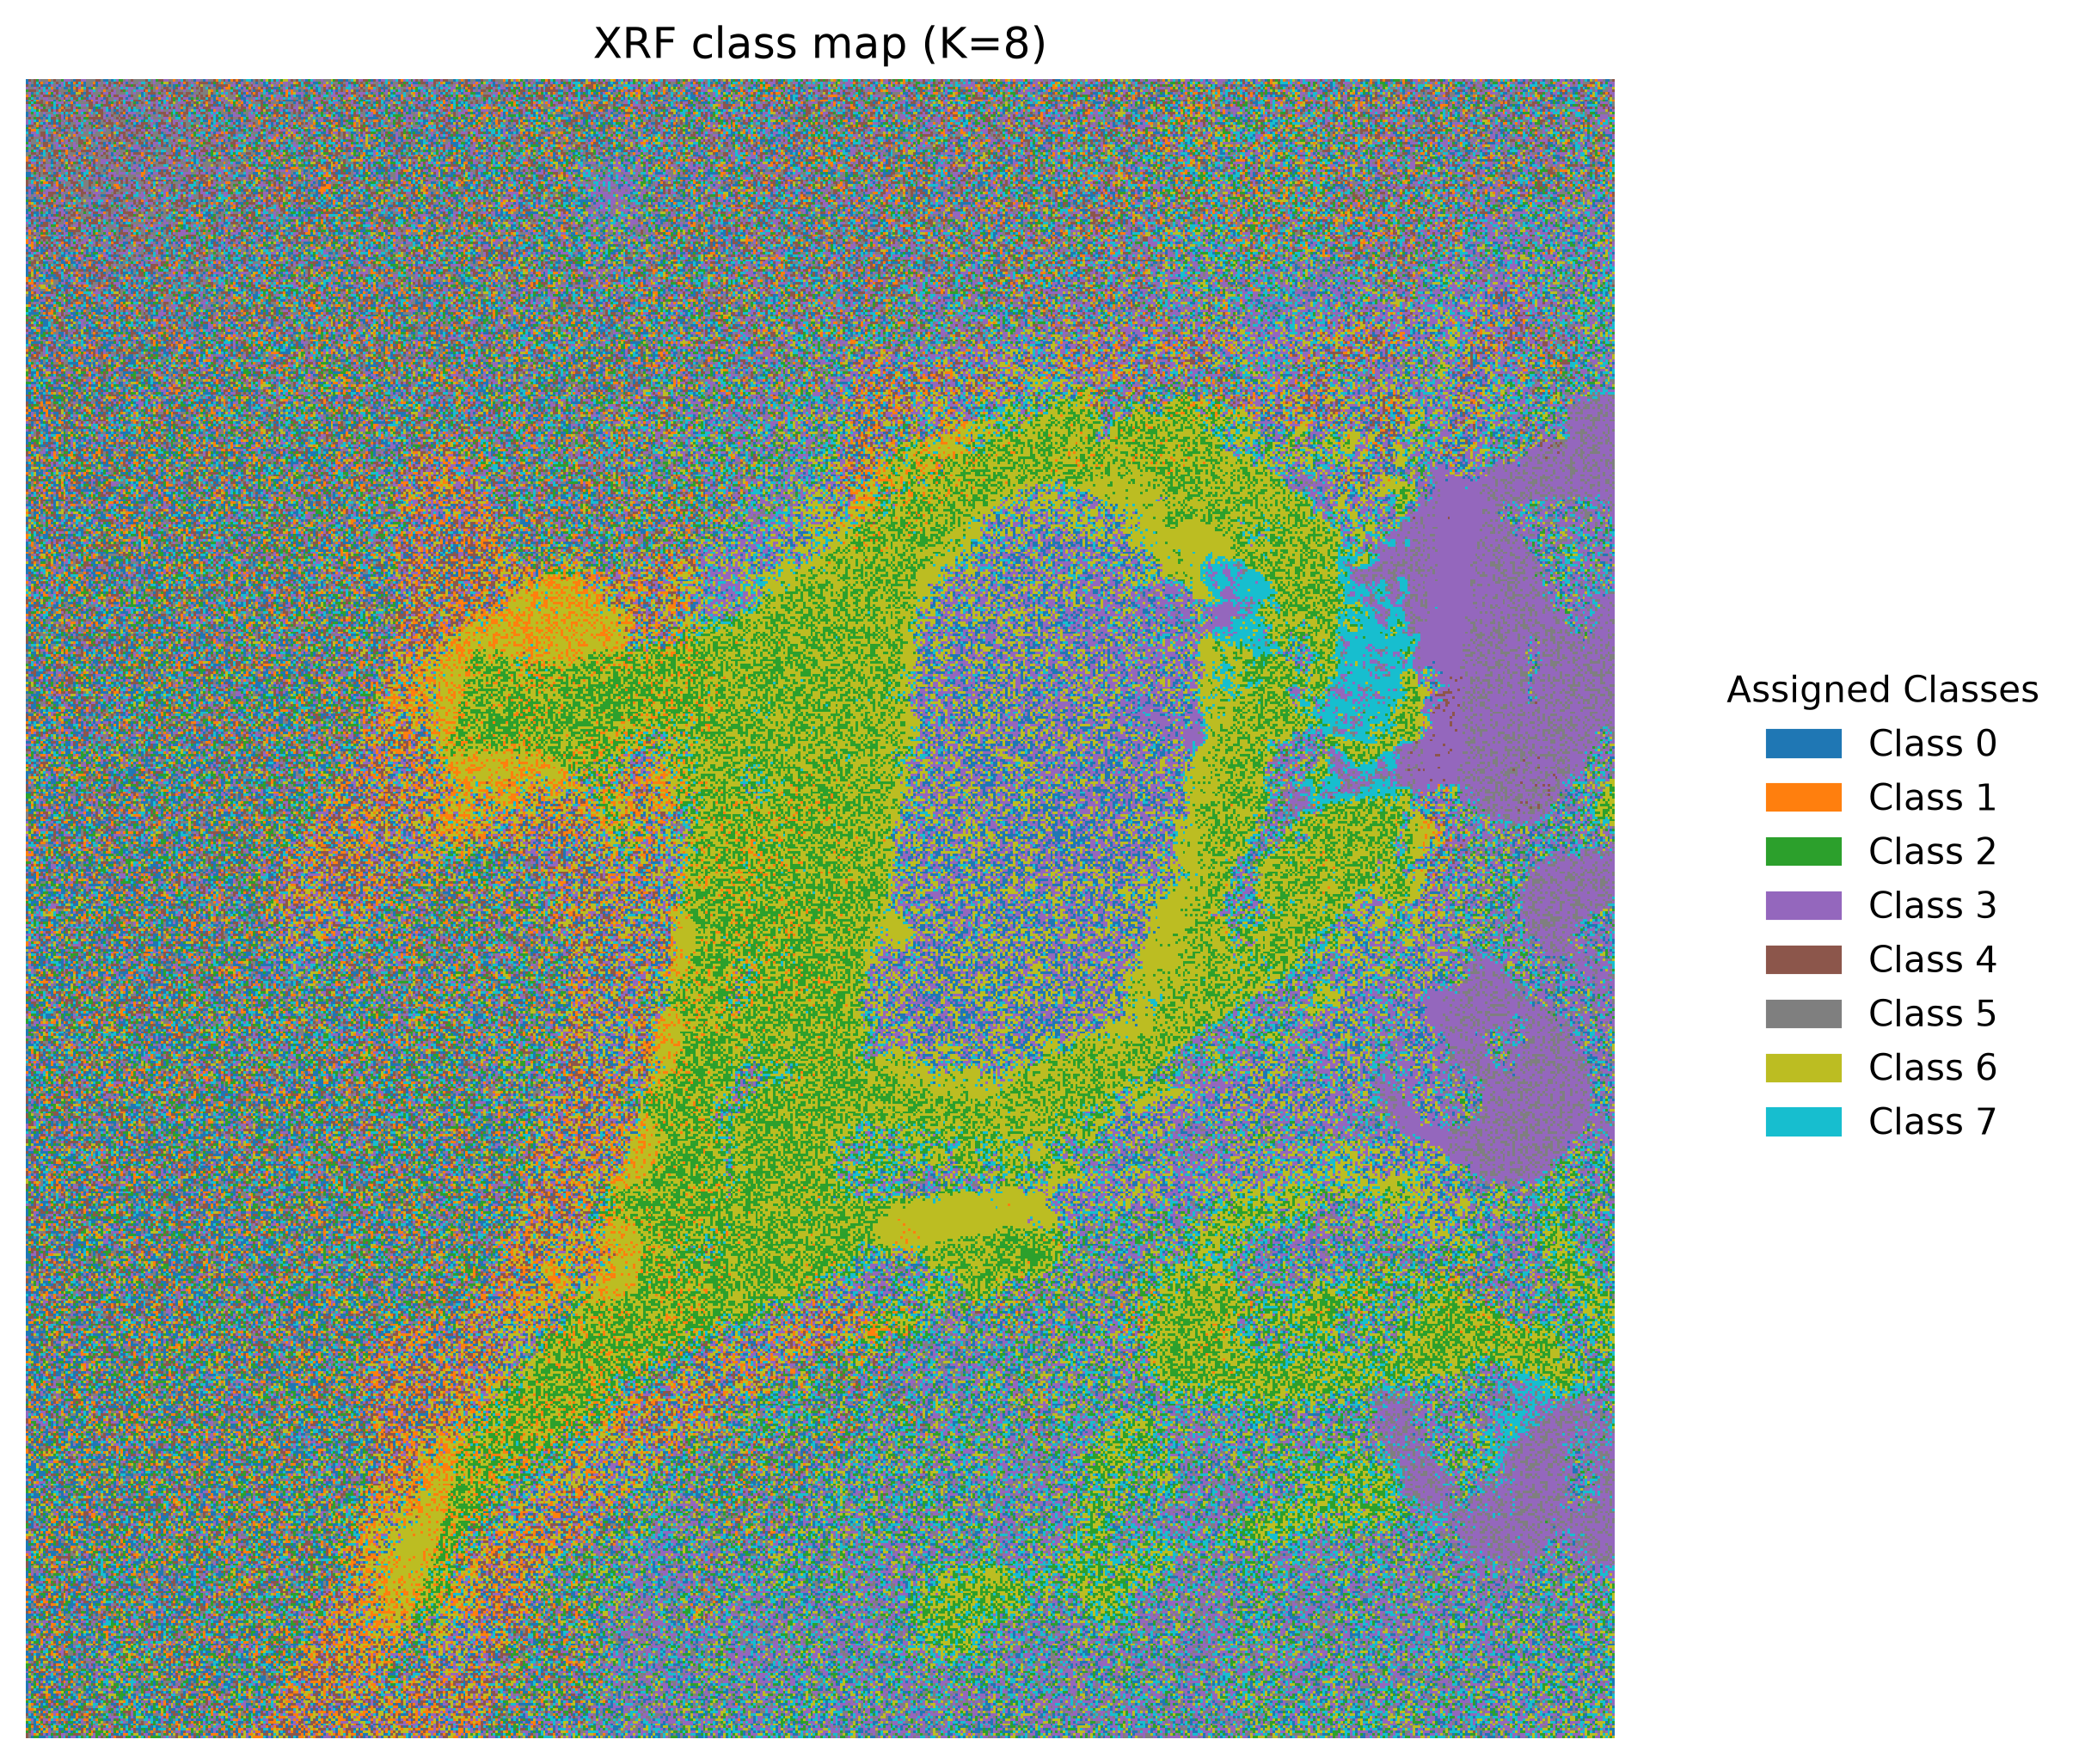

In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors

#  Load mask and reconstruct class map
mask = np.load(PROCESSED_DATA_DIR / "page_001_mask.npy")
class_map = Spatial_Analyzer.Reconstruct_Class_Map(labels, mask)

# Set up a discrete colormap for the clusters
# Use number of clusters to truncate 'tab10' exactly at the optimal number of clusters (optimal_k)
discrete_cmap = plt.get_cmap("tab10", optimal_k)
discrete_cmap.set_bad(color="black")  # Assign black color to NaN values (background)

# Create a figure to visualize the class map
fig, ax = plt.subplots(figsize=(8, 8), dpi=300)

# vmin and vmax set to -0.5 and optimal_k - 0.5 to center the colors on integer class labels 
im = ax.imshow(
    class_map, cmap=discrete_cmap, vmin=-0.5, vmax=optimal_k - 0.5, interpolation="nearest"
)

ax.set_title(f"XRF class map (K={optimal_k})")
ax.axis("off")  # Hide axes for better visualization

# Use categorical colorbar to show class labels
legend_patches = []
for i in range(optimal_k):
    patch = mpatches.Patch(color=discrete_cmap(i), label=f"Class {i}")
    legend_patches.append(patch)

# Legend outside the plot
ax.legend(
    handles=legend_patches,
    title="Assigned Classes",
    loc="center left",
    bbox_to_anchor=(1.05, 0.5),
    frameon=False,
)

plt.tight_layout()
plt.show()

import tifffile

# Replace NaNs with a background value (like -1) so TIFF can save it
export_map = np.nan_to_num(class_map, nan=-1.0).astype(np.float32)

# Save the raw cluster array as a 32-bit TIFF
tifffile.imwrite("Cluster_Segmentation_Map.tiff", export_map)
np.save(PROCESSED_DATA_DIR / "page_001_class_map.npy", class_map)

Processing Class 0...


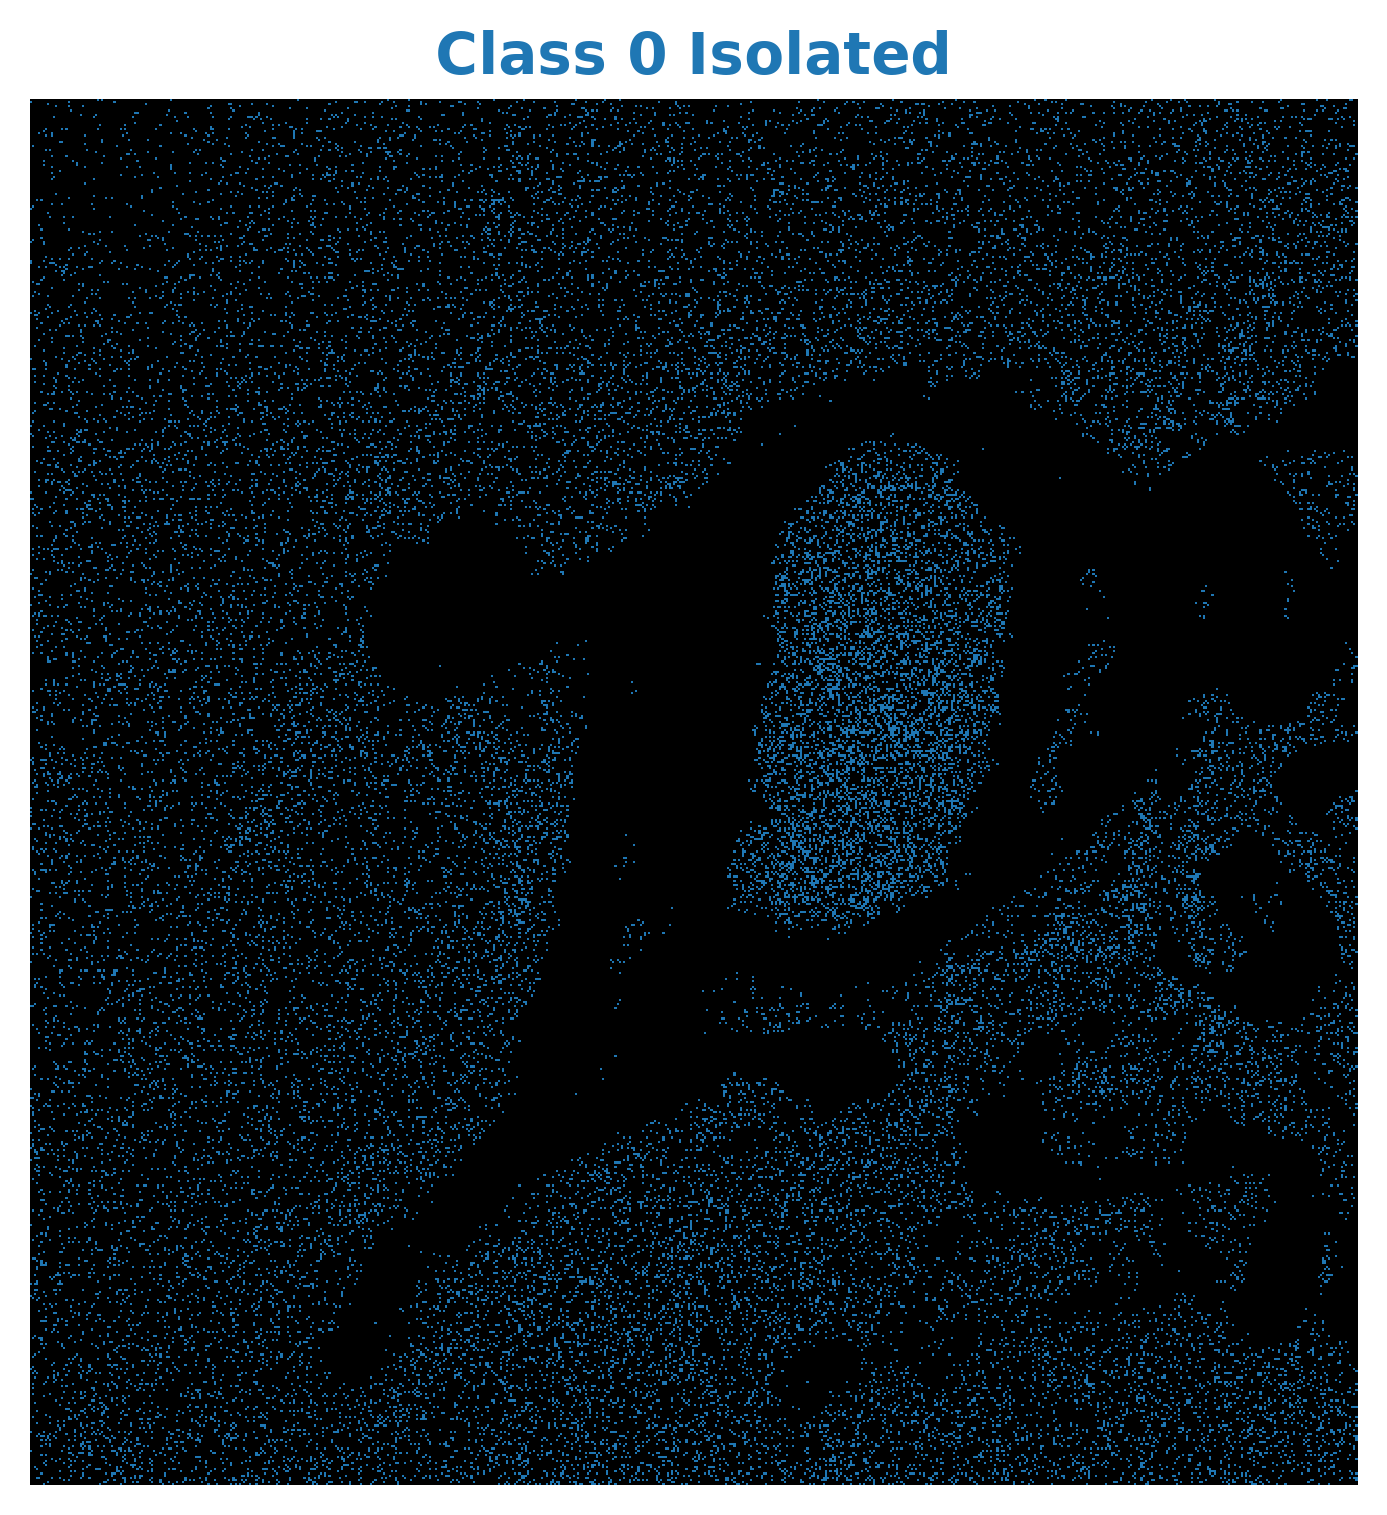

Processing Class 1...


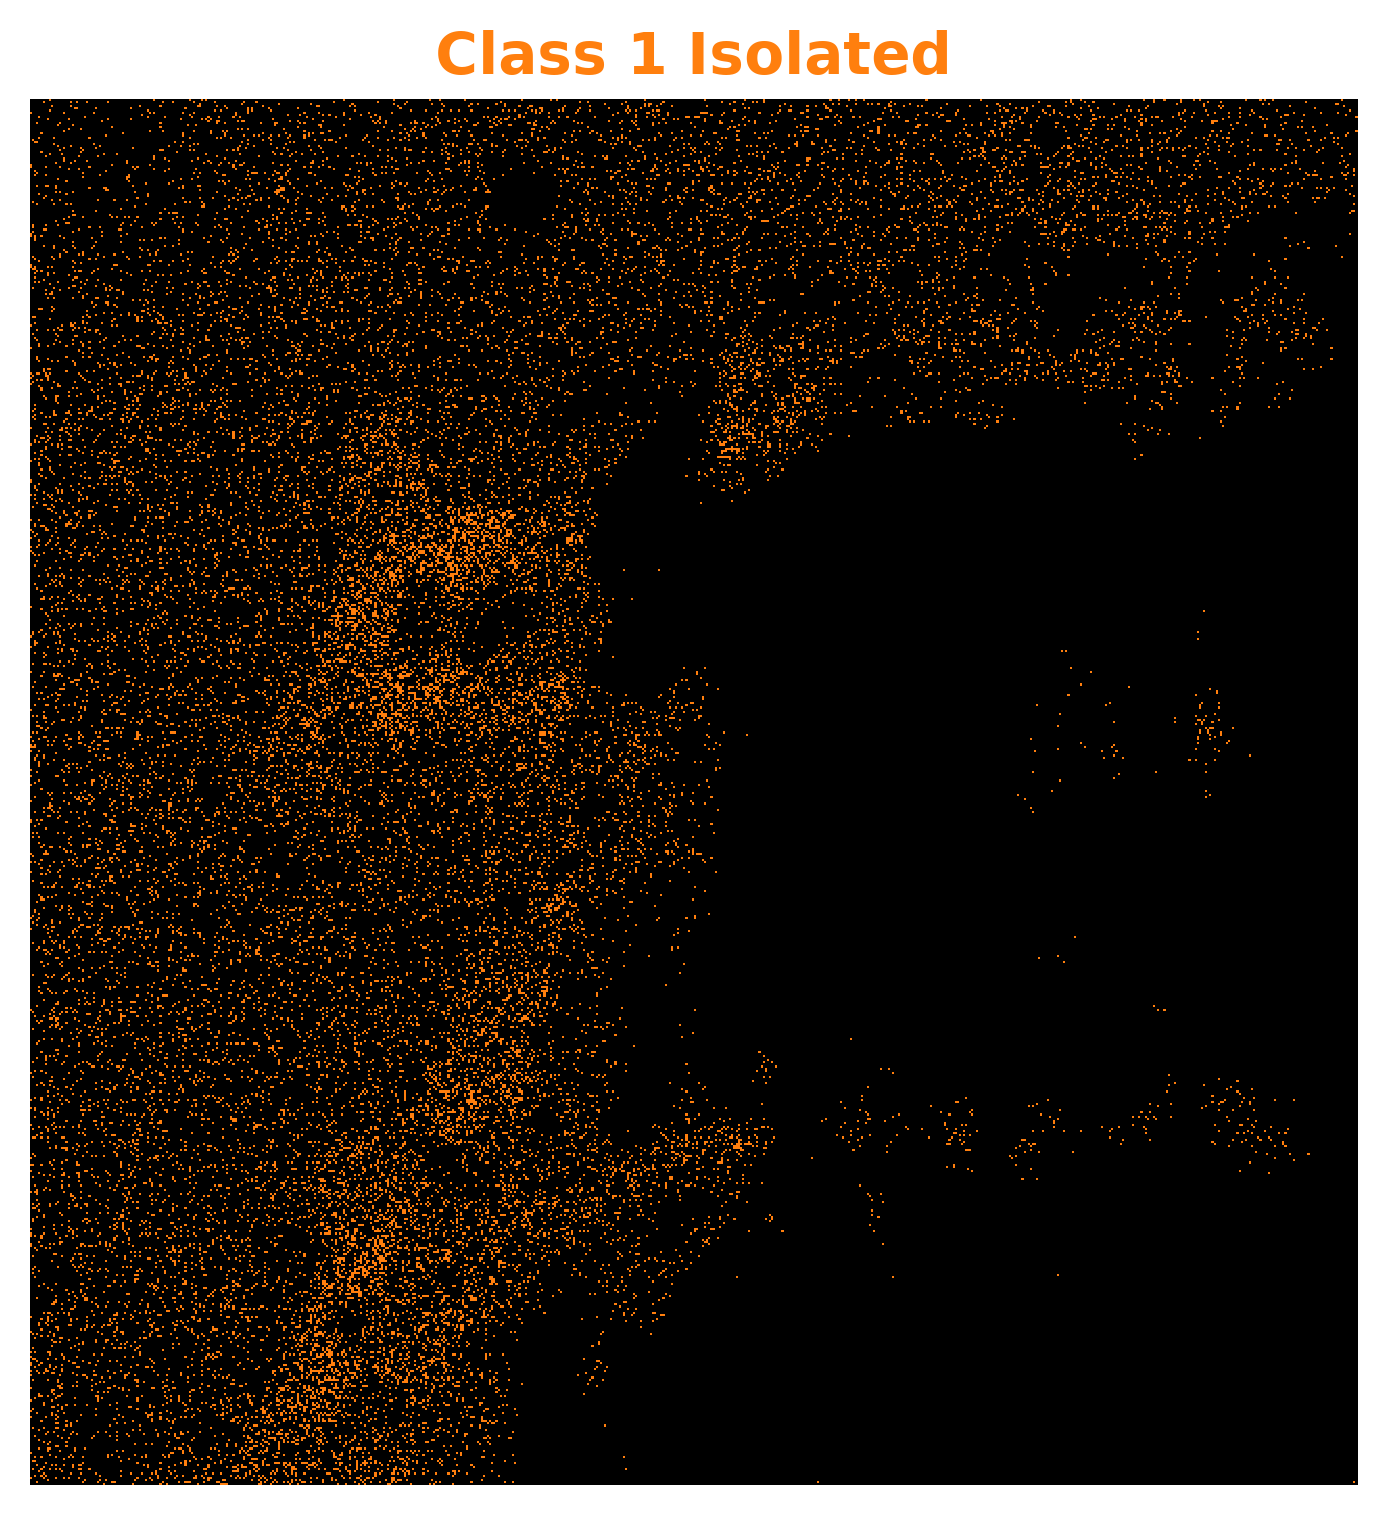

Processing Class 2...


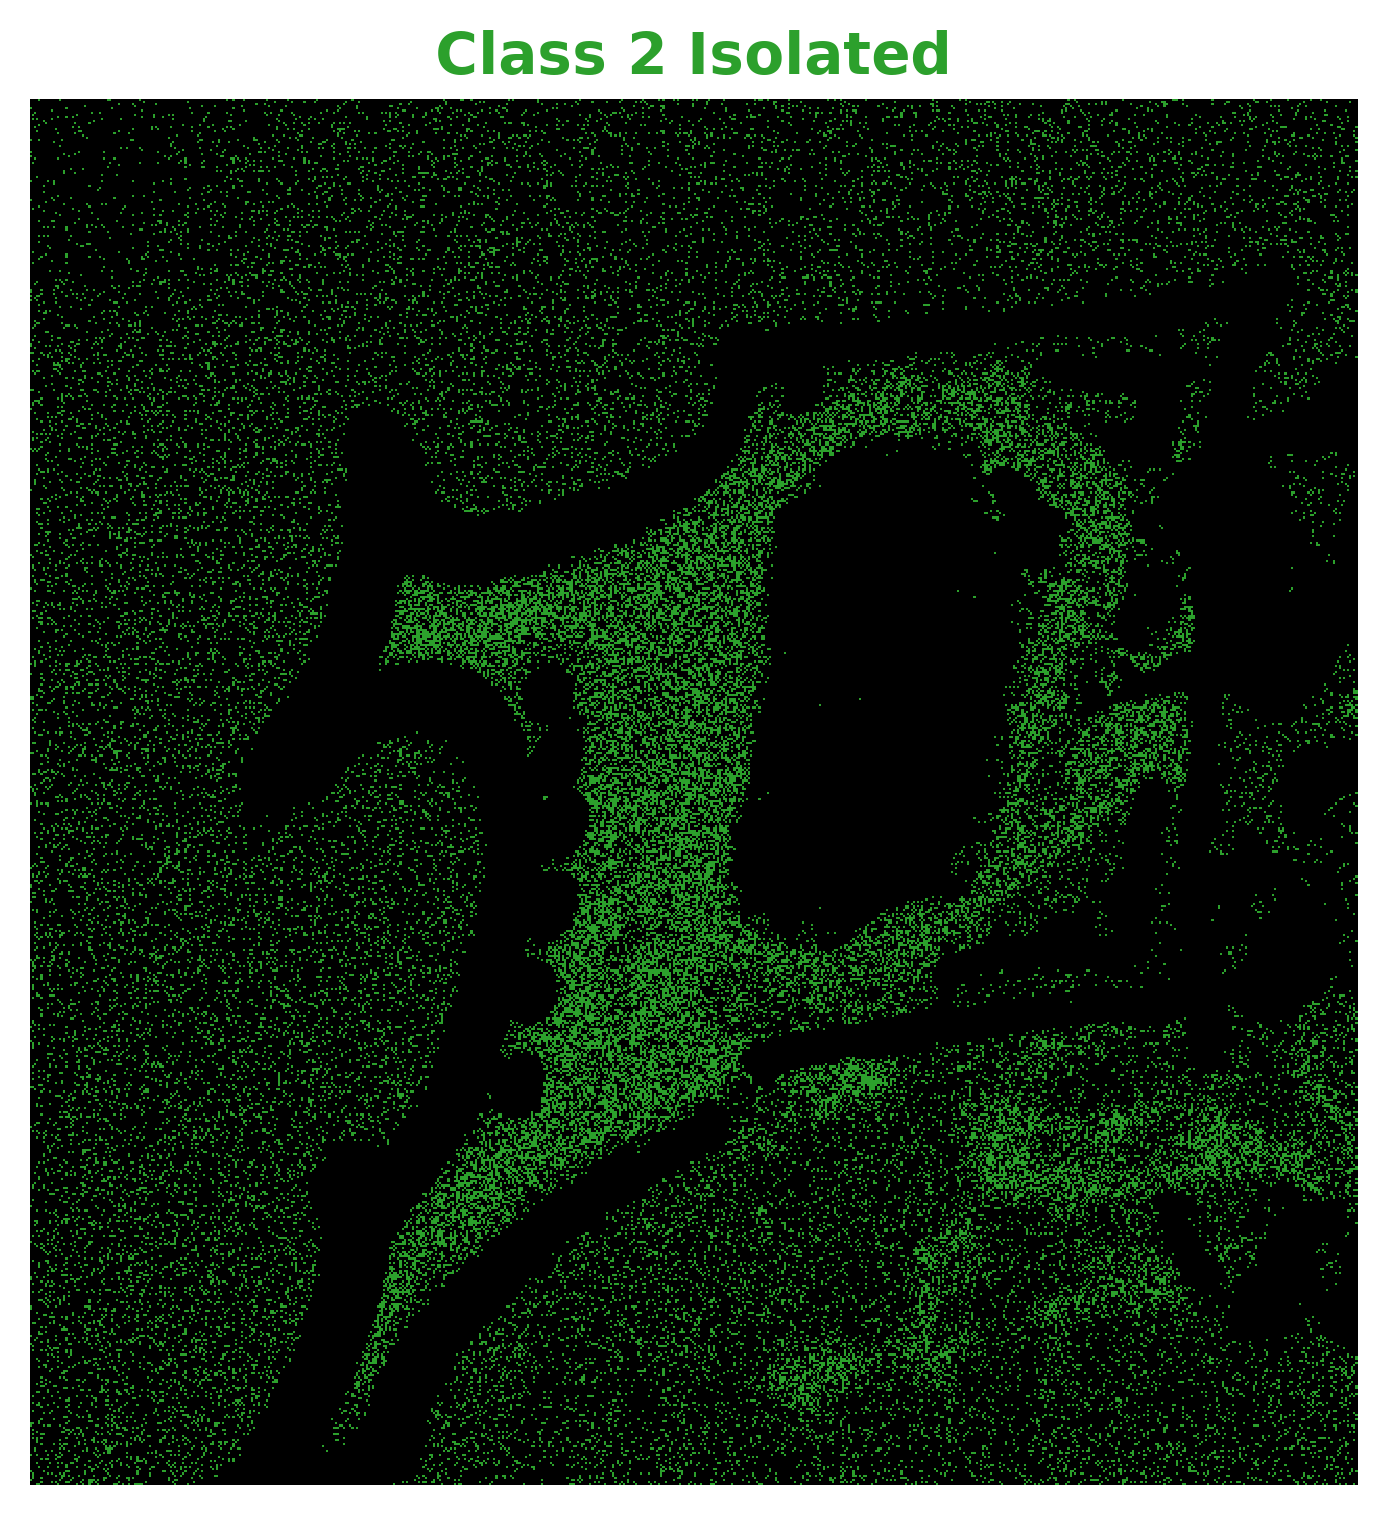

Processing Class 3...


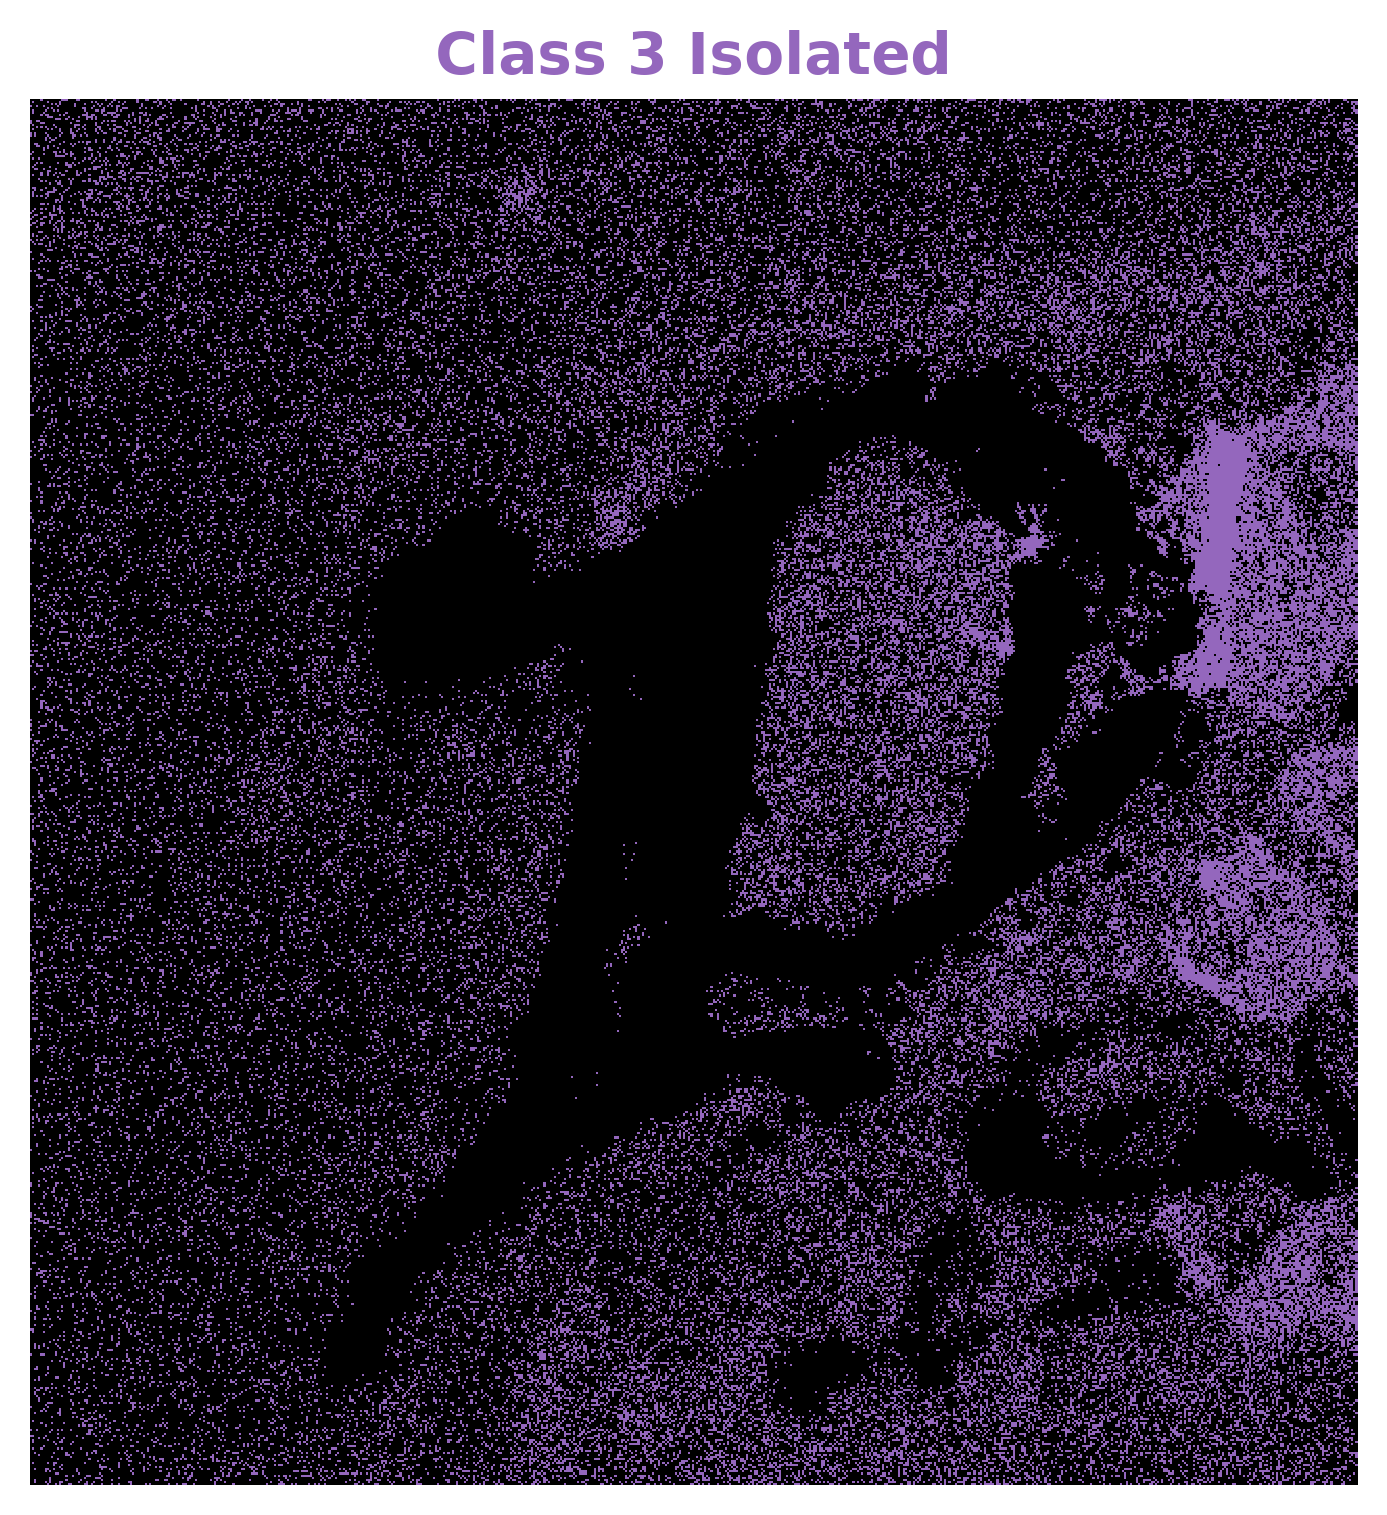

Processing Class 4...


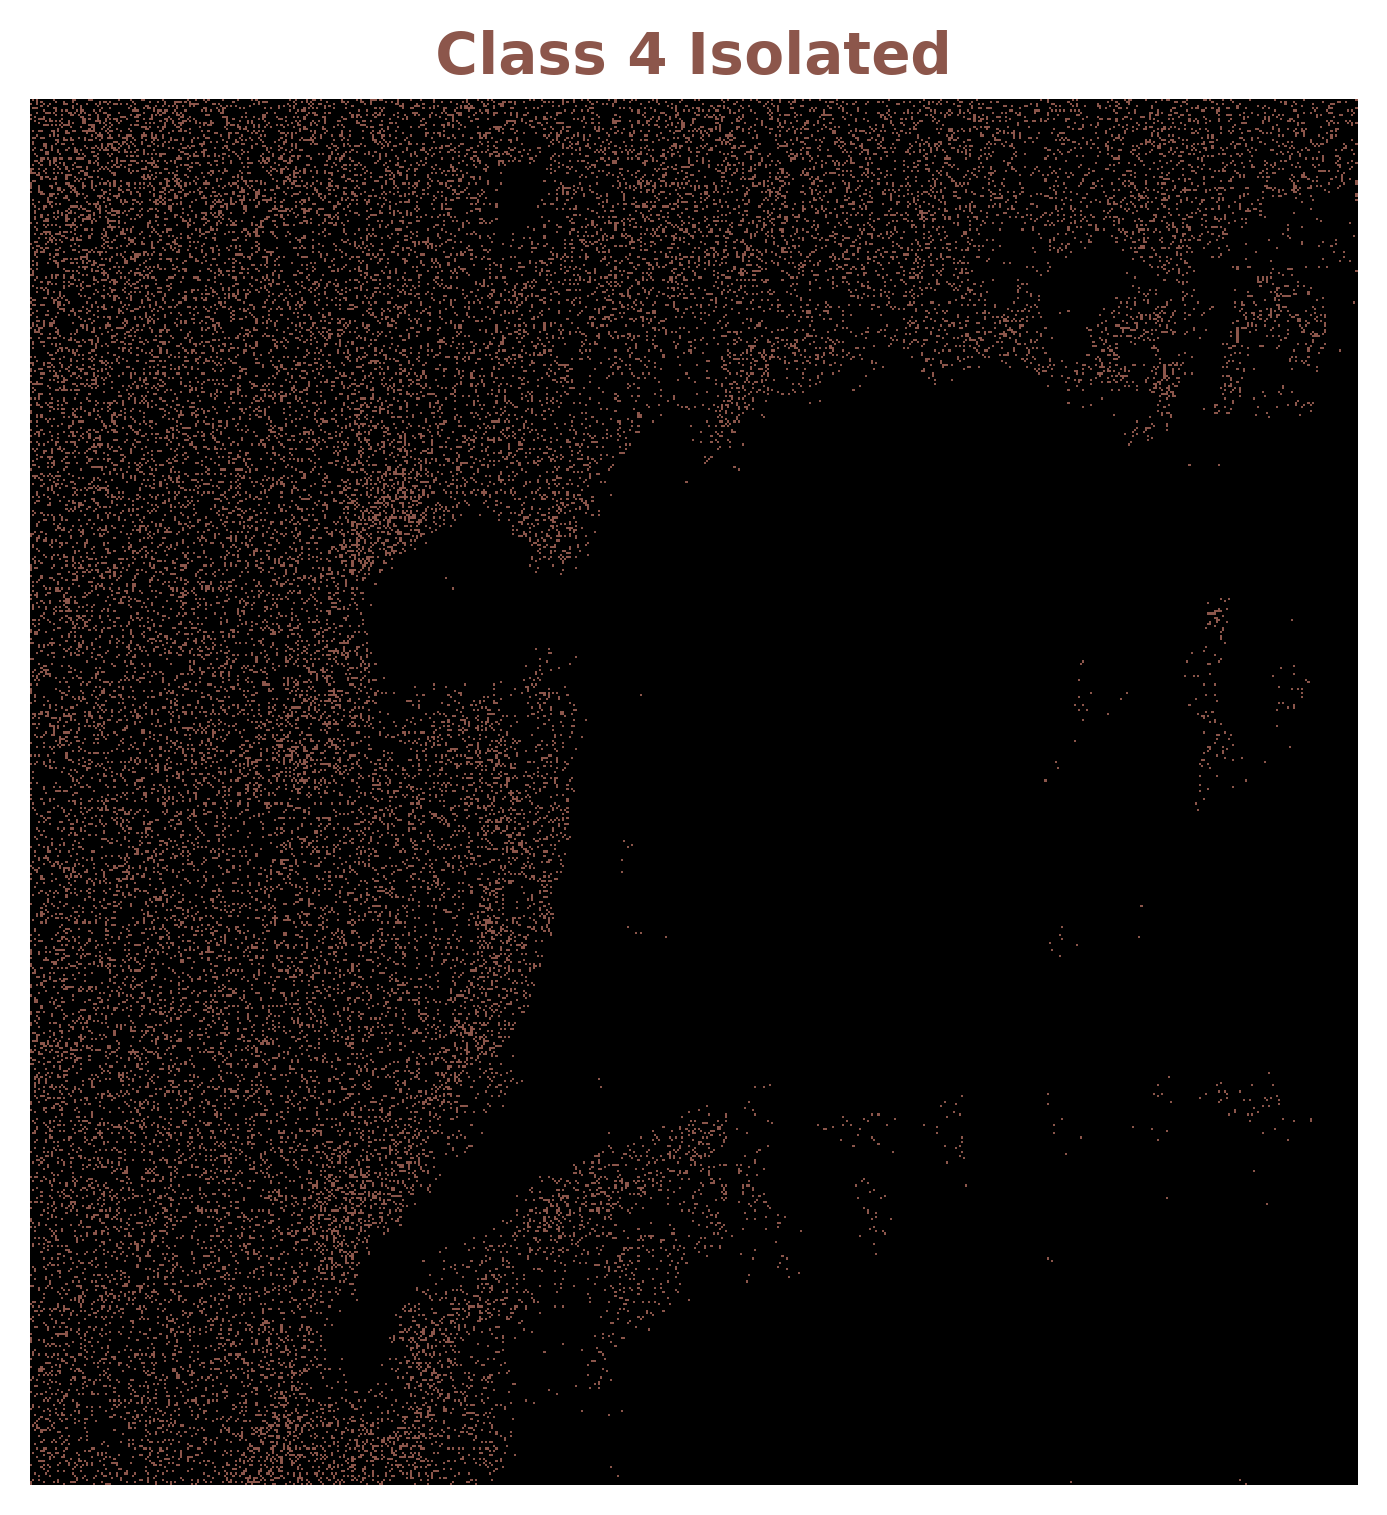

Processing Class 5...


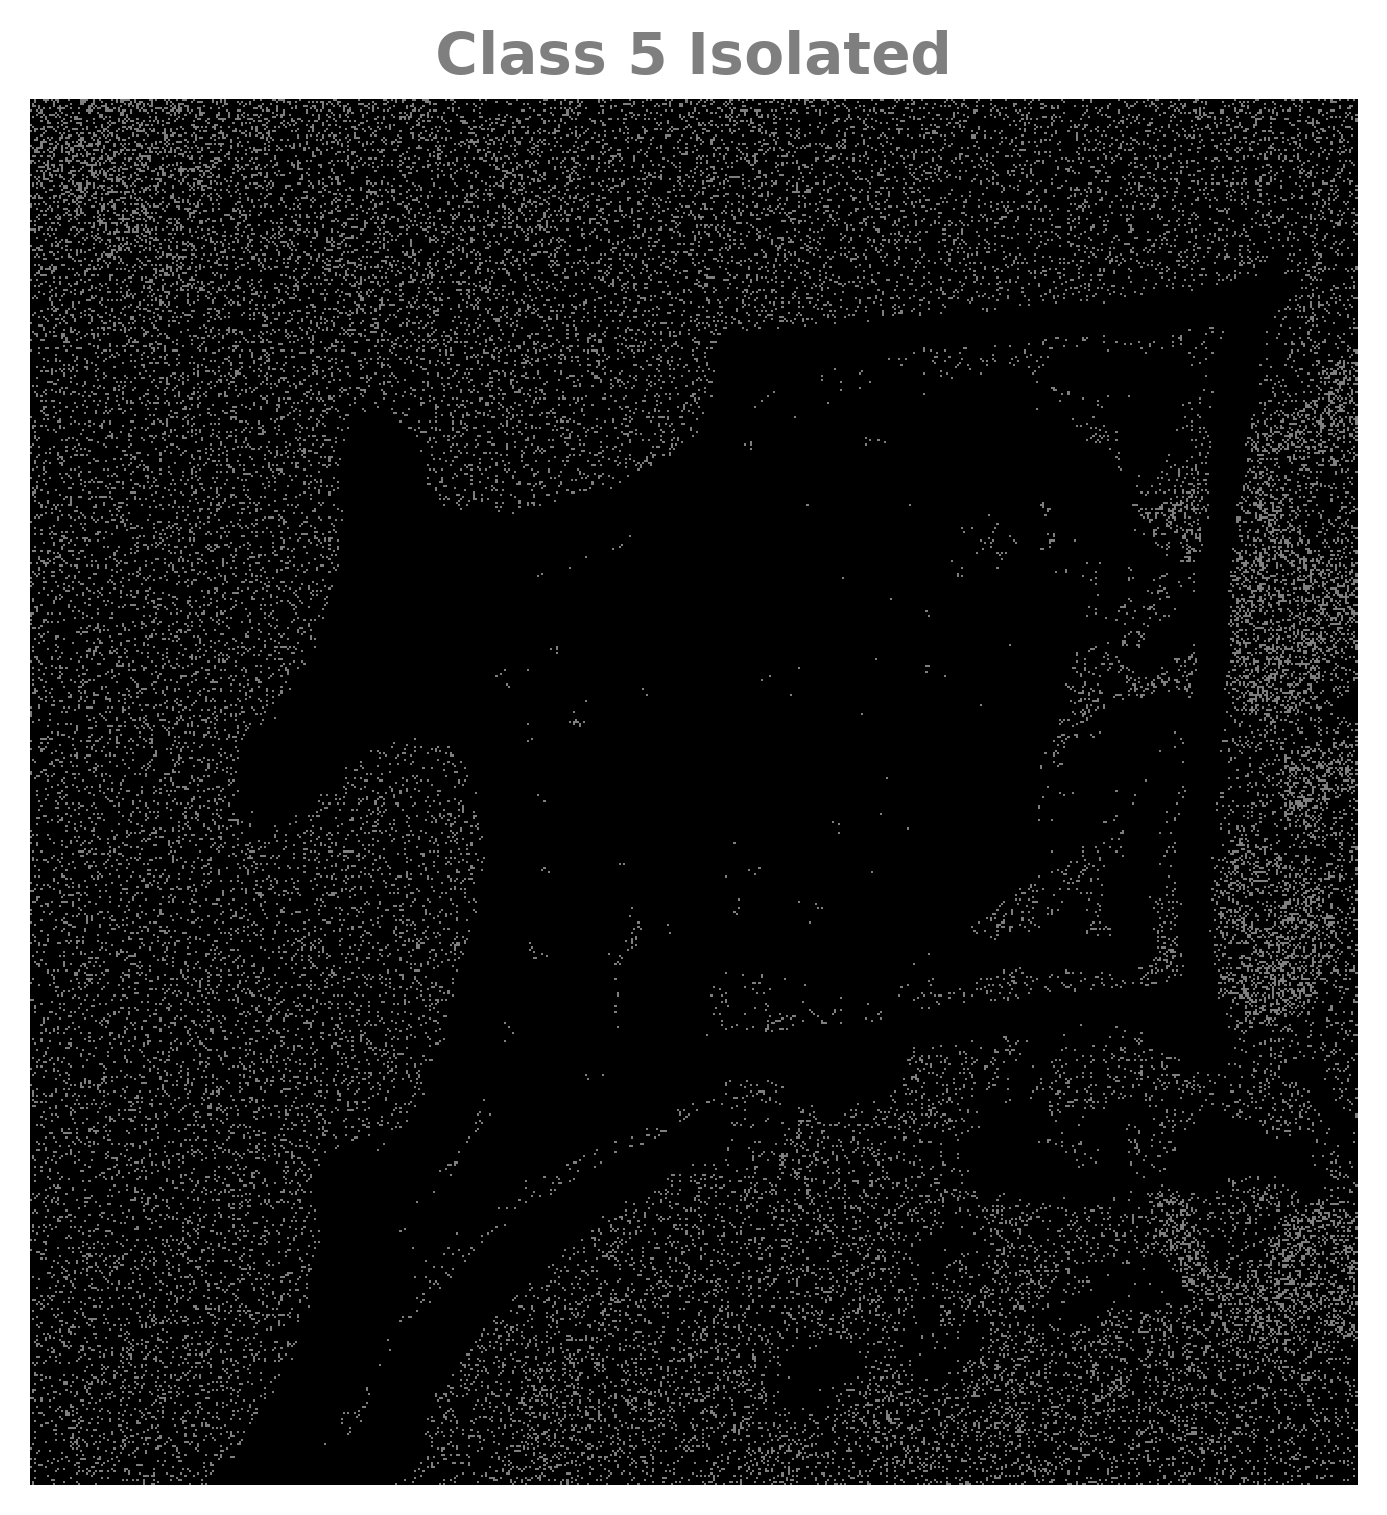

Processing Class 6...


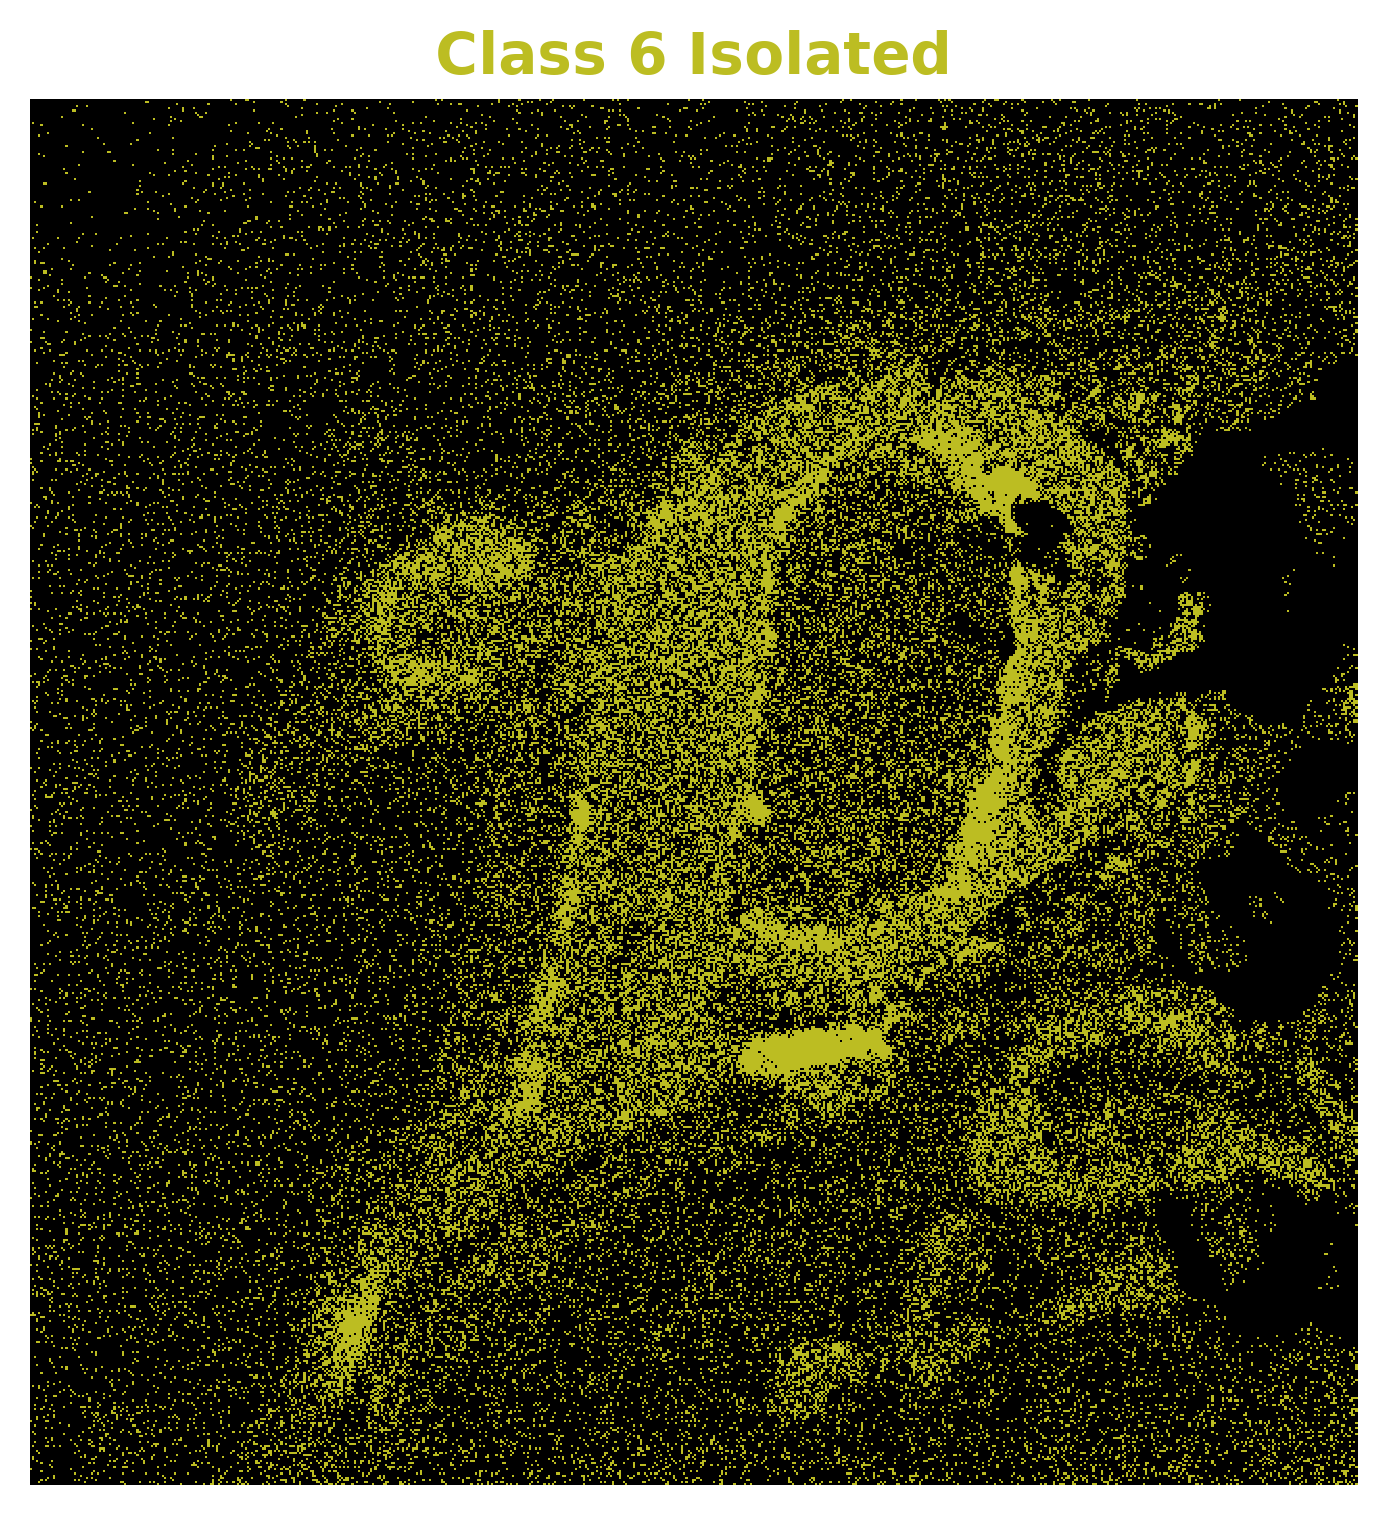

Processing Class 7...


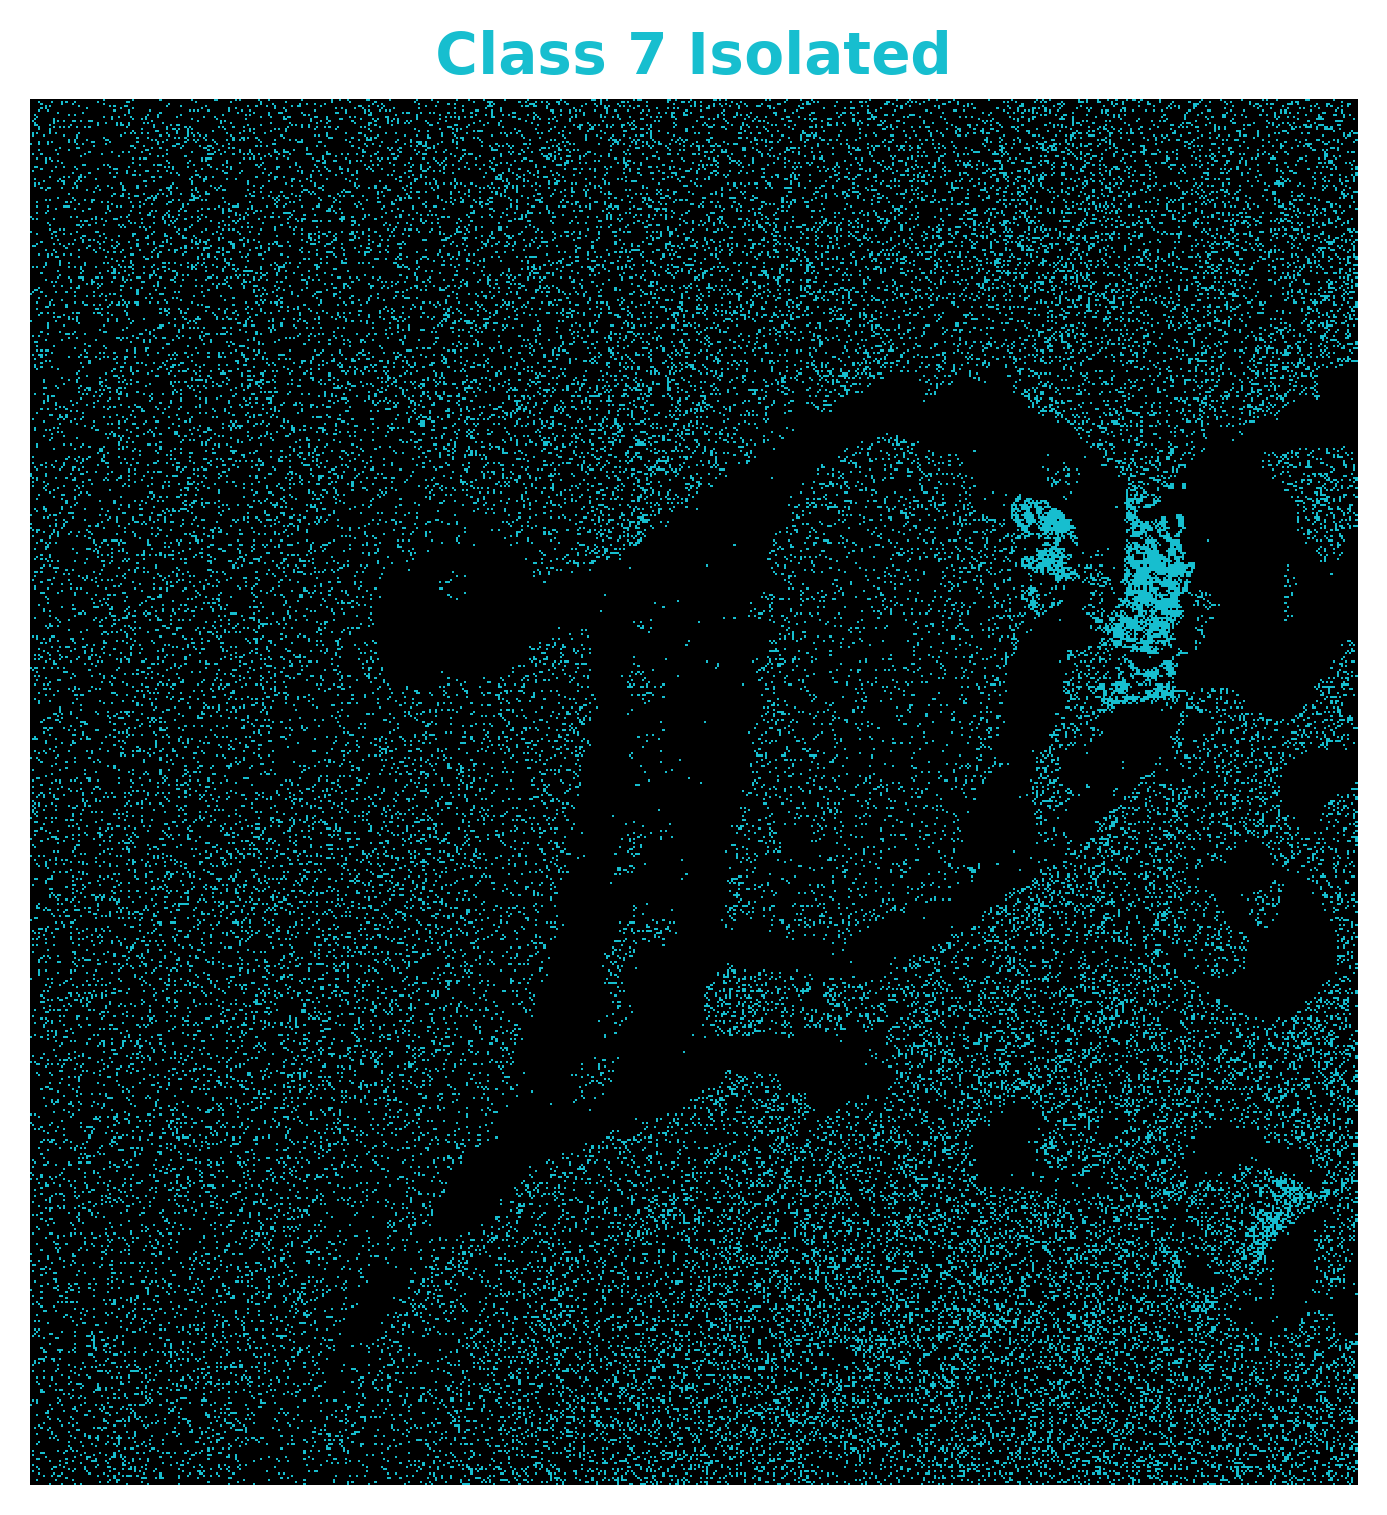

Export completed successfully!


In [12]:
import os
export_folder = str(FIGURES_DIR)
os.makedirs(export_folder, exist_ok=True)

base_cmap = plt.get_cmap("tab10", optimal_k)
for k in range(optimal_k):
    print(f"Processing Class {k}...")

    # Isolate the current cluster
    isolated_mask = (class_map == k).astype(np.uint8)

    # A. Export Raw TIFF using os.path.join (bulletproof path joining)
    tiff_filename = os.path.join(export_folder, f"Cluster_{k}_Fiji_Mask.tiff")
    tifffile.imwrite(tiff_filename, isolated_mask * 255)

    # B. Plot and Save High-Res PNG
    cluster_color = base_cmap(k)
    binary_cmap = mcolors.ListedColormap(["black", cluster_color])

    fig, ax = plt.subplots(figsize=(6, 6), dpi=300)
    ax.imshow(isolated_mask, cmap=binary_cmap, interpolation="nearest")
    ax.set_title(f"Class {k} Isolated", fontsize=14, weight="bold", color=cluster_color)
    ax.axis("off")

    # Save the PNG using os.path.join
    png_filename = os.path.join(export_folder, f"Cluster_{k}_Visual.png")
    plt.savefig(png_filename, bbox_inches="tight", facecolor="white")

    plt.show()
    plt.close(fig)

print("Export completed successfully!")